## Read and Setup the Dataset

In [1]:
import pandas as pd
fp ="../data/coffee_prices.csv"
df = pd.read_csv(fp)

In [2]:
cols = ["date", "signal"]
df.columns = cols

## Setup Observation Logging 
We will be using Jinja templates to log observations about the data as we discover them. The observations are collected in a list and then logged to KMDS finally.

### Basic Descriptive Statistics

In [3]:
ts_obs = []

In [4]:
from scipy.stats import iqr
import numpy as np
data = df.signal.values
# Calculate the IQR
# Default percentiles are (25, 75)
iqr_value = iqr(data)
print(f"IQR: {iqr_value}")

# Calculate Q1 and Q3 manually using numpy for demonstration of bounds calculation
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
print(f"Q1: {Q1}, Q3: {Q3}")

# Calculate bounds
lower_bound = Q1 - 1.5 * iqr_value
upper_bound = Q3 + 1.5 * iqr_value
outlier = (data < lower_bound) | (data > upper_bound)
df["outlier"] = outlier

IQR: 82.1401717620974
Q1: 93.7875061035156, Q3: 175.927677865613


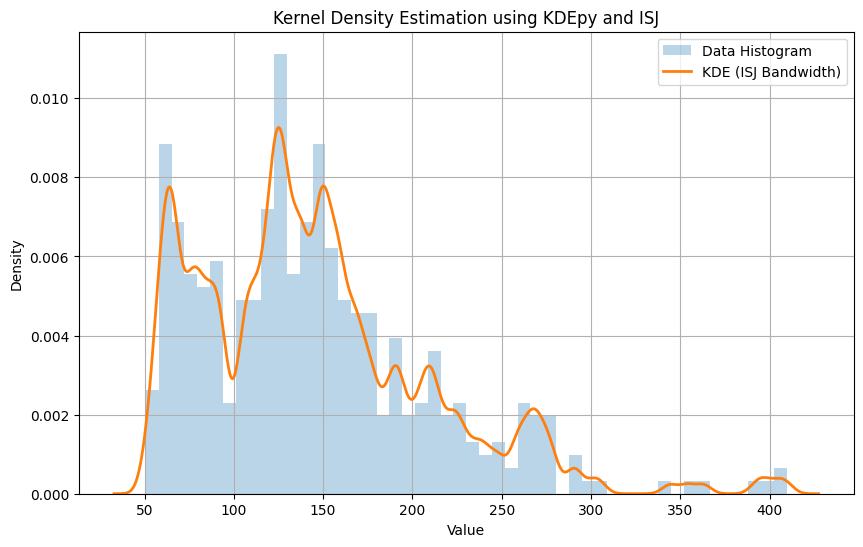

In [5]:

import matplotlib.pyplot as plt
from KDEpy import FFTKDE
from scipy.stats import norm

# 1. Generate or define a sample signal (multimodal data)
np.random.seed(42)
data = df.signal.values

# 2. Compute density estimates using 'ISJ' - Improved Sheather Jones
# FFTKDE is fast for large datasets
x, y = FFTKDE(kernel='gaussian', bw='ISJ').fit(data).evaluate(2**10)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, density=True, alpha=0.3, label='Data Histogram')
plt.plot(x, y, label='KDE (ISJ Bandwidth)', linewidth=2)
plt.title('Kernel Density Estimation using KDEpy and ISJ')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
from observation_log import ObservationTemplates
ObservationTemplates.DESCRIPTIVE_STATISTICS

'Descriptive Statistics: There were {{num_samples}} samples, taken at a frequency of {{sampling_rate}}. The mean was {{ "%0.2f" | format(mean)}} and the standard deviation was {{ "%0.2f" | format(std)}}. Evaluation of the histogram and kernel density plots reveals a {{modality}} distribution.'

In [7]:
data = {"num_samples": df.shape[0],
"sampling_rate": "monthly (first day of month)",
"mean" : np.mean(df.signal),
"std": np.std(df.signal),
 "modality": "multimodal"
}

from jinja2 import Template
j2_template = Template(ObservationTemplates.DESCRIPTIVE_STATISTICS)
rendered_output = j2_template.render(data)

In [8]:
from observation_log import ObsCat
obs = (ObsCat.DESCRIPTIVE_STATISTICS, rendered_output)
ts_obs.append(obs)

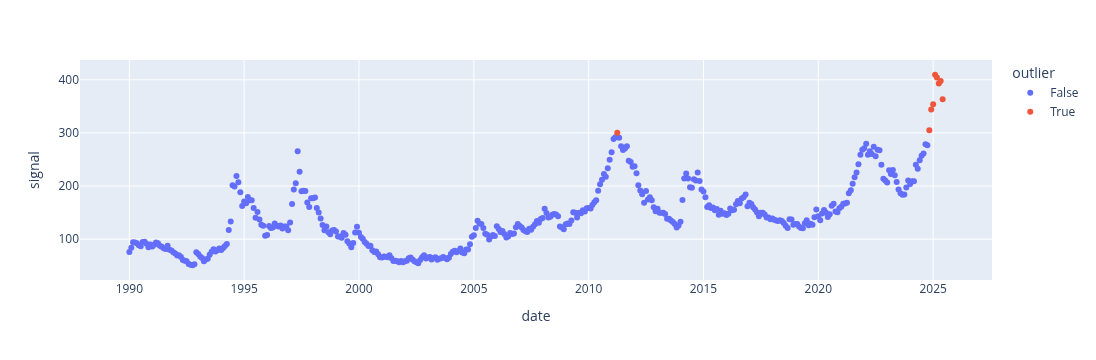

In [9]:
import plotly.express as px


# Create the line plot with markers
fig = px.scatter(df, x="date", y="signal", color="outlier")

# Display the figure
fig.show()

In [10]:
outlier_prop = df[df.outlier == True].shape[0]/df.shape[0]

In [11]:
outlier_prop

0.02112676056338028

In [12]:
ObservationTemplates.OUTLIERS

'Outliers: Using the interquartile range (IQR) metric, the proportion of outliers was found to be {{ "%0.2f" | format(outlier_proportion)}}.'

In [13]:
data = {"outlier_proportion": outlier_prop
}

j2_template = Template(ObservationTemplates.OUTLIERS)
rendered_output = j2_template.render(data)

In [14]:

obs = (ObsCat.OUTLIERS, rendered_output)
ts_obs.append(obs)

In [15]:
ObservationTemplates.RAW_PLOTS

'Raw Plots: {{remarks}}'

In [16]:
data = {"remarks": """It looks like outliers are concentrated at the end of the series mostly. Very high prices seem recent"""
}

j2_template = Template(ObservationTemplates.RAW_PLOTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.RAW_PLOTS, rendered_output)
ts_obs.append(obs)

## Run SSA
1. Define a window size
2. Run SSA
3. Analyze the eigen value spectrum

In [17]:
series = df.signal
series.index = df.date

In [18]:
from ssalib import SingularSpectrumAnalysis
wdw = 12
ssa = SingularSpectrumAnalysis(series, window=wdw)

In [19]:
ssa.decompose()

SingularSpectrumAnalysis(timeseries=<Series shape=(426,)>, window=12, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

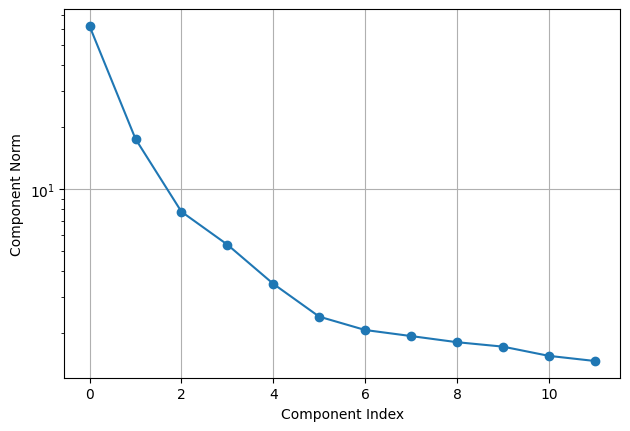

In [20]:
fig, ax = ssa.plot(n_components=12, marker='o')
plt.grid(True)

In [21]:
import numpy as np

# Suppose 's' contains the singular values from SVD
# s = [sigma1, sigma2, ..., sigmaL]
eigenvalues = ssa.eigenvalues
total_variance = np.sum(eigenvalues)
exp_var = {"var_comp-" + str(i+1) : (eigenvalues[i]/total_variance).item() for i in range(eigenvalues.shape[0])}
cum_var = {"var_comp-" + str(i+1) : (np.sum(eigenvalues[:i+1])/total_variance).item() for i in range(eigenvalues.shape[0])}

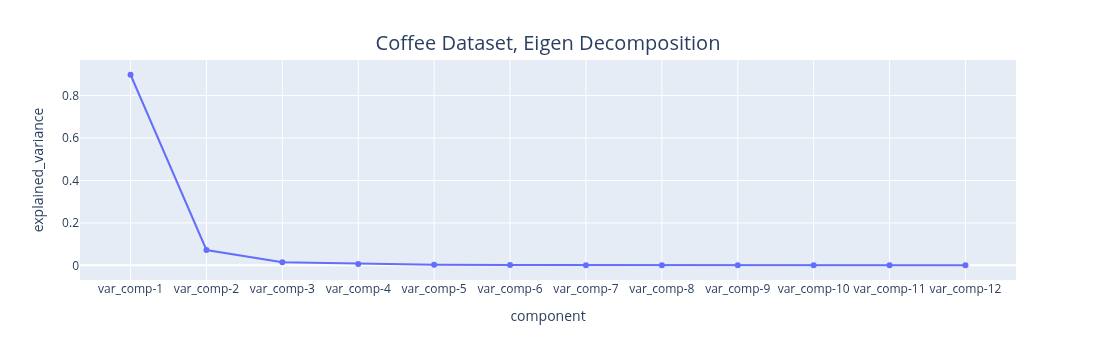

In [22]:
import plotly.express as px
df_eig = pd.DataFrame.from_dict(exp_var, orient="index").reset_index()
df_eig.columns = ["component", "explained_variance"]
# Create the line plot with markers
fig = px.line(df_eig, x="component", y="explained_variance", markers=True)
fig.update_layout(
    title={
        'text': "Coffee Dataset, Eigen Decomposition",
        'y':0.9, # Position (0-1)
        'x':0.5, # Position (0-1)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=20)
    }
)
# Display the figure
fig.show()

In [23]:
def num_comp_for_threshold(thrsh):
    num_comp = 1
    for k, v in cum_var.items():
        if v < thrsh:
            num_comp += 1
    return num_comp
    

In [24]:
nc = num_comp_for_threshold(0.98)

In [25]:
nc

3

In [26]:
df_cv = pd.DataFrame.from_dict(cum_var, orient="index").reset_index()
df_cv.columns = ["component", "explained_variance"]

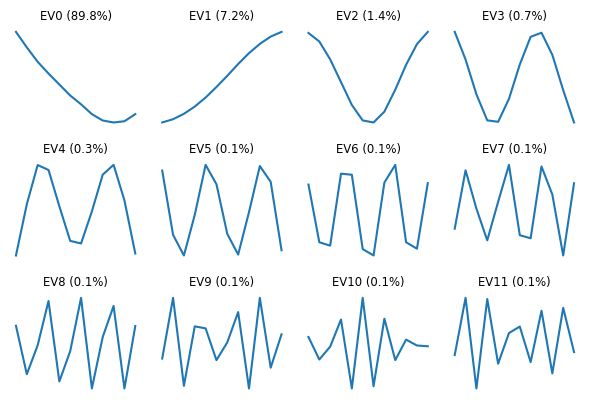

In [27]:
fig, axes = ssa.plot(kind='vectors')

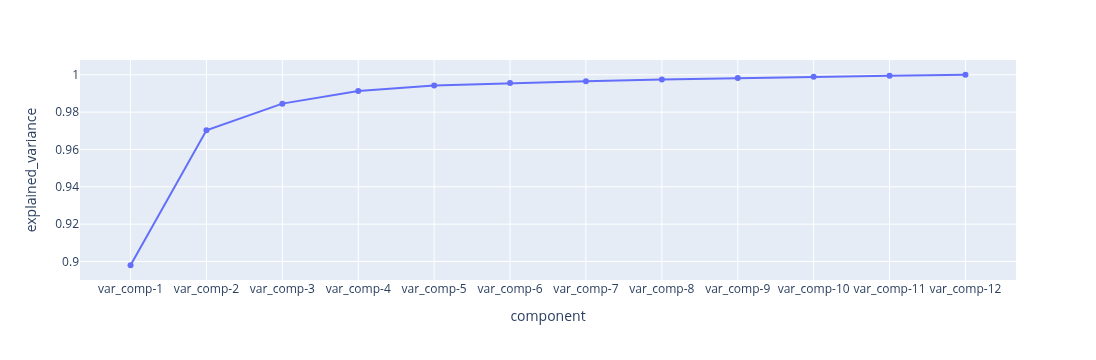

In [28]:



# Create the line plot with markers
fig = px.line(df_cv, x="component", y="explained_variance", markers=True)

# Display the figure
fig.show()

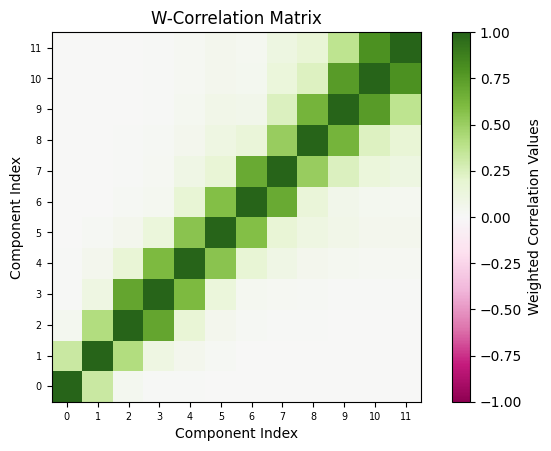

In [29]:
fig, ax = ssa.plot(kind='wcorr', n_components=12)
_ = ax.set_xlabel('Component Index')
_ = ax.set_ylabel('Component Index')
cbar = ax.collections[0].colorbar
cbar.set_label('Weighted Correlation Values')

Grouping is applied with due consideration to:
1. Which components really matter - explain materially relevant variance
2. Which components are contributing related information (they are correlated)
3. The term "Trend", "Seasonality" and "Noise" are used for historic reasons, if you want to call them differently, you can. For example if a grouping has a more meaningful name in your problem, you can use that.

## Apply Grouping

In [30]:
ssa.reconstruct(groups={'Trend': [0, 1,2], 'Seasonal': [], "residuals":[3,4,5,6,7,8,9,10,11]})

SingularSpectrumAnalysis(timeseries=<Series shape=(426,)>, window=12, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

## Residual Analysis

In [31]:
ssa["residuals"]

date
1990-01-01   -0.136271
1990-02-01   -0.050938
1990-03-01    0.070015
1990-04-01    0.049737
1990-05-01    0.013882
                ...   
2025-02-01    0.409849
2025-03-01    0.113260
2025-04-01   -0.140345
2025-05-01   -0.045920
2025-06-01   -0.396270
Name: residuals, Length: 426, dtype: float64

In [32]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [33]:

# 3. Perform the Durbin-Watson test
dw_statistic = durbin_watson(ssa["residuals"].values)

print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 1.7065303752398788


<Axes: ylabel='Density'>

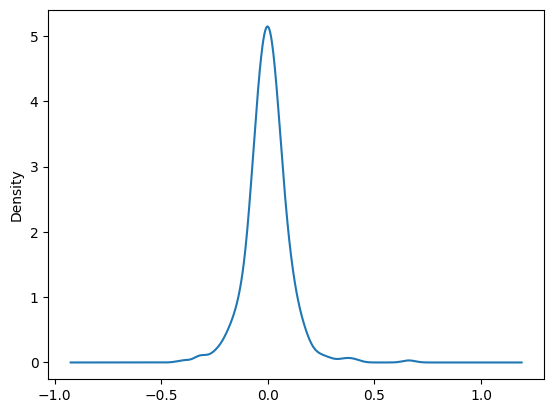

In [34]:
ssa["residuals"].plot.kde()

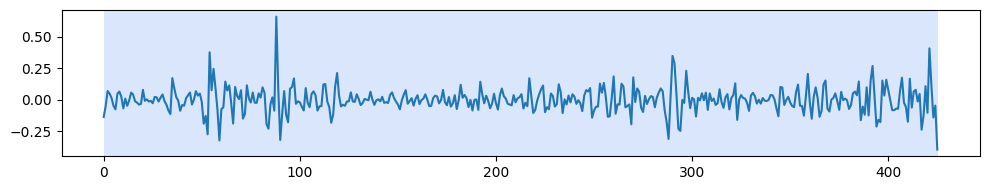

In [35]:
import ruptures as rpt
import matplotlib.pyplot as plt
from math import log
algo = rpt.Pelt(model="rbf").fit(ssa["residuals"].values)
rec_pen = 2*log(ssa["residuals"].shape[0],2)
# 3. Predict the change points
# The 'pen' parameter controls the sensitivity (higher penalty, fewer change points)
result = algo.predict(pen=10)

# 4. Display the results (optional, requires matplotlib)
rpt.display(ssa["residuals"].values, result)
plt.show()

1. The residuals do not explain a lot of variation in the signal
2. Change point detection on the residuals, run with the assumption that we don't know the the change points apriori, with a
penalty $\beta = 2 . \log(N)$ suggests there are no change points in the noise. The implication is that unexplained variance does not change over the observation period. The change points of interest are in the trend and seasonal component.

In [36]:
result

[426]

In [37]:
trend_data = {"date": df.date.values, "trend": ssa["Trend"].values, "raw":ssa["ssa_preprocessed"].values}
df_trend = pd.DataFrame.from_dict(trend_data, orient="columns")

In [38]:
df_trend

,date,trend,raw
0,1990-01-01,-0.920259,-1.056529
1,1990-02-01,-0.880491,-0.931430
2,1990-03-01,-0.849277,-0.779262
3,1990-04-01,-0.832516,-0.782779
4,1990-05-01,-0.822813,-0.808931
...,...,...,...
421,2025-02-01,3.636790,4.046639
422,2025-03-01,3.852233,3.965493
423,2025-04-01,3.933058,3.792713
424,2025-05-01,3.910143,3.864223


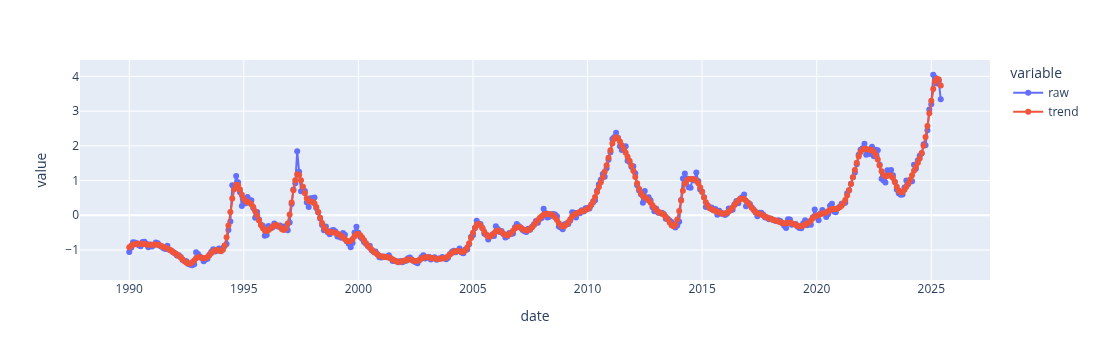

In [39]:
# Create the line plot with markers
fig = px.line(df_trend, x="date", y=["raw","trend"], markers=True)

# Display the figure
fig.show()

In [40]:
ObservationTemplates.SMOOTHED_PLOTS

'Smoothed Plots: Visually, the Singular Spectrum Analysis (SSA) appears to achieve {{reconstruction_quality}} reconstruction. {{notes_for_cycles_trends_seasonality}}'

In [41]:
data = {"reconstruction_quality": "a very good",
        "notes_for_cycles_trends_seasonality": """Trend observed for some parts of the data, trend-cycles are present, no apparent seasonality evident."""
}

j2_template = Template(ObservationTemplates.SMOOTHED_PLOTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.SMOOTHED_PLOTS, rendered_output)
ts_obs.append(obs)

In [42]:
obs = (ObsCat.CHANGE_POINTS, ObservationTemplates.CHANGE_POINTS)
ts_obs.append(obs)


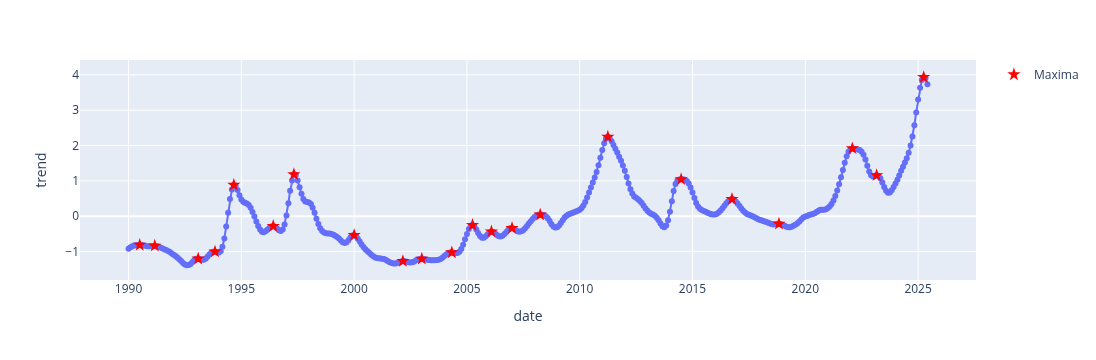

In [43]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
the_signal = df_trend.trend.values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
fig = px.line(df_trend, x="date", y="trend", markers=True)

#plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
fig.add_trace(
    go.Scatter(
        x= x[peaks_indices], y= the_signal[peaks_indices],
        mode='markers', # Set mode to markers
        name='Maxima', # Name for the legend
        marker=dict(color='red', size=10, symbol='star'), # Customize the marker style
        showlegend=True
    )
)


# Display the figure
fig.show()

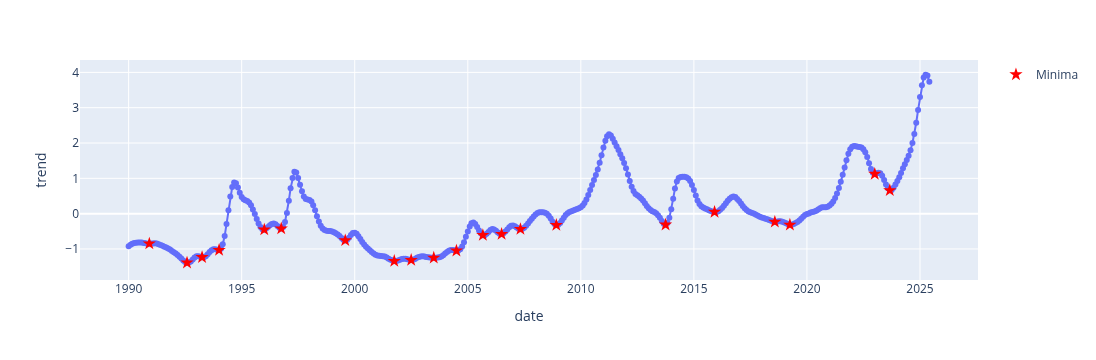

In [44]:

the_signal = -df_trend.trend.values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
the_signal = df_trend.trend.values

# 3. Plot the results (optional, but helpful for visualization)
fig = px.line(df_trend, x="date", y="trend", markers=True)

#plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
fig.add_trace(
    go.Scatter(
        x= x[peaks_indices], y= the_signal[peaks_indices],
        mode='markers', # Set mode to markers
        name='Minima', # Name for the legend
        marker=dict(color='red', size=10, symbol='star'), # Customize the marker style
        showlegend=True
    )
)




In [45]:
df_trend["date"] = pd.to_datetime(df_trend.date)
df_trend.rename(columns={"trend": "ssa"}, inplace=True)

In [46]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

# Apply lowess
smoothed_05 = lowess(df_trend.raw, df_trend.date, frac=0.05) # frac is fraction of data used
smoothed_10 = lowess(df_trend.raw, df_trend.date, frac=0.1) # frac is fraction of data used
from scipy.signal import savgol_filter
# Apply filter: window size 51, polynomial order 3
smoothed_savgol_51 = savgol_filter(df_trend.raw, 51, 3)
smoothed_savgol_21 = savgol_filter(df_trend.raw, 21, 3)

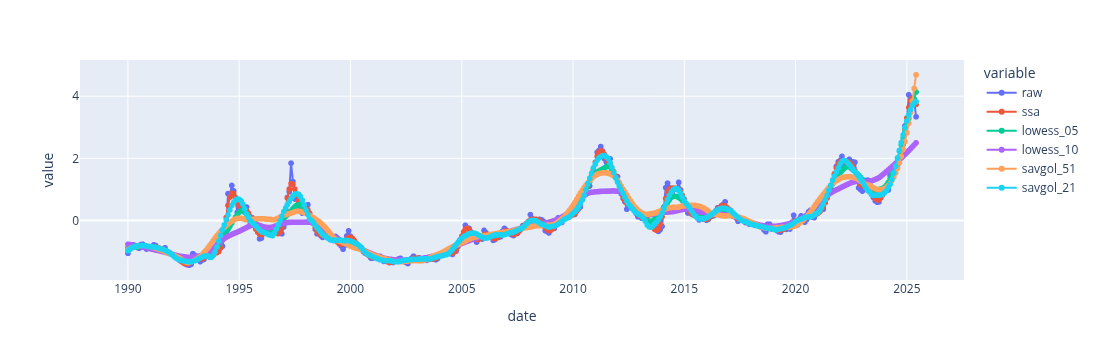

In [47]:
df_trend["lowess_05"] = smoothed_05[:,1]
df_trend["lowess_10"] = smoothed_10[:,1]
df_trend["savgol_51"] = smoothed_savgol_51
df_trend["savgol_21"] = smoothed_savgol_21
fig = px.line(df_trend, x="date", y=["raw","ssa", "lowess_05", "lowess_10", "savgol_51", "savgol_21"], markers=True)

# Display the figure
fig.show()

In [48]:
ObservationTemplates.GROUPING

'Grouping: Based on the correlation plot, the following components can be grouped together: {{ comma_sep_components }}.'

In [49]:
data = {"comma_sep_components": "(0,1,2)"
}

j2_template = Template(ObservationTemplates.GROUPING)
rendered_output = j2_template.render(data)
obs = (ObsCat.GROUPING, rendered_output)
ts_obs.append(obs)

In [50]:
ts_obs

[(<ObsCat.DESCRIPTIVE_STATISTICS: 'DESCRIPTIVE-STATISTICS'>,
  'Descriptive Statistics: There were 426 samples, taken at a frequency of monthly (first day of month). The mean was 144.91 and the standard deviation was 65.39. Evaluation of the histogram and kernel density plots reveals a multimodal distribution.'),
 (<ObsCat.OUTLIERS: 'OUTLIERS'>,
  'Outliers: Using the interquartile range (IQR) metric, the proportion of outliers was found to be 0.02.'),
 (<ObsCat.RAW_PLOTS: 'RAW-PLOTS'>,
  'Raw Plots: It looks like outliers are concentrated at the end of the series mostly. Very high prices seem recent'),
 (<ObsCat.SMOOTHED_PLOTS: 'SMOOTHED-PLOTS'>,
  'Smoothed Plots: Visually, the Singular Spectrum Analysis (SSA) appears to achieve a very good reconstruction. Trend observed for some parts of the data, trend-cycles are present, no apparent seasonality evident.'),
 (<ObsCat.CHANGE_POINTS: 'CHANGE-POINTS'>,
  "Change Points: The chosen approach for capturing change points involves working 

In [51]:
data = {"explained_variance": df_cv.loc[2, "explained_variance"].item()*100
}

j2_template = Template(ObservationTemplates.EXPLAINED_VARIANCE)
rendered_output = j2_template.render(data)
obs = (ObsCat.EXPLAINED_VARIANCE, rendered_output)
ts_obs.append(obs)

In [52]:
ObservationTemplates.EXPLAINED_VARIANCE

'Explained Variance: The smoothed signal explains {{ "%0.2f" | format(explained_variance)}}% of the variance.'

In [53]:
ObservationTemplates.ESTIMATED_NOISE

'Estimated Noise: The unexplained variance (noise) is estimated to be {{ "%0.2f" | format(noise_estimate)}}%.'

In [54]:
data = {"noise_estimate": (1 - df_cv.loc[2, "explained_variance"].item())*100
}

j2_template = Template(ObservationTemplates.ESTIMATED_NOISE)
rendered_output = j2_template.render(data)
obs = (ObsCat.ESTIMATED_NOISE, rendered_output)
ts_obs.append(obs)

In [55]:
ObservationTemplates.SPECIFIC_COMMENTS

'Specific Comments: The noise appears to be {{correlated}}. {{additional_comments}}'

In [56]:
ac = "With this dataset, it is reasonable to use the first 3 components to approximate the signal and the remainder to be noise."
ac += " Since the Durbin-Watson statistic is in the 1.5 to 2.5 range (1.7), we can treat the noise as independent"
ac += " Further, PELT reported no change points in the noise, so we can treat the noise as Independent Identically Distributed"
ac += " If your downstream task, needs to approximate the data as the sum of a smooth signal with IID noise, with this data, it is a reasonable choice."
data = {"correlated": "uncorrelated",
        "additional_comments": ac
       }

j2_template = Template(ObservationTemplates.SPECIFIC_COMMENTS)
rendered_output = j2_template.render(data)
obs = (ObsCat.SPECIFIC_COMMENTS, rendered_output)
ts_obs.append(obs)

In [57]:

file_path = "../data/coffee_ts_observations.txt"
with open(file_path, 'w') as file:
    for cat, obs in ts_obs:
        # Convert the named tuple to a string and add a newline character
        file.write(f"Category: {cat.value}\n")
        file.write(f"Observation: {obs}\n")

## Knowledge Base Logging

In [58]:
from kmds.ontology.kmds_ontology import *
from kmds.tagging.tag_types import ExploratoryTags
kaw = KnowledgeExtractionExperimentationWorkflow("coffee_prices_35_year_analysis", namespace=onto)

In [59]:
from kmds.ontology.intent_types import IntentType
exp_obs_list = []
observation_count :int = 1
e1 = ExploratoryObservation(namespace=onto)

In [60]:
for cat, obs in ts_obs:
    observation_count += 1
    e = ExploratoryObservation(namespace=onto)
    e.finding = obs
    e.finding_sequence = observation_count
    e.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
    e.intent = IntentType.DATA_UNDERSTANDING.value
    exp_obs_list.append(e)

kaw.has_exploratory_observations = exp_obs_list  

In [61]:
from owlready2 import *
from kmds.utils.path_utils import get_package_kb_path
KNOWLEDGE_BASE = "../data/kmds/coffee_prices_analysis.xml"
onto.save(file=KNOWLEDGE_BASE, format="rdfxml")